In [9]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_selector import Data_selector
from feature_adder import Feature_adder
from feature_selector import Feature_selector
from logs.logger import CustomLogger
from models import Random_Forest, Linear, Polynomial, XGBoost, LinearL1
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

logger = CustomLogger(name="model_main", log_file_name='model_main.log').get_logger()
from main import *

In [18]:
write_predictions = False

number_mimo = 1
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 4
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)
logger.info(f"Csv file has bean labeled successfully")

ds = Data_selector(df)
df_modified = ds.select_peaks(goodness=3)
logger.info(f"Rows have been selected successfully")

X, y = select_features_and_get_X_and_y(df_modified,is_mimo=is_mimo,number_mimo=number_mimo)
logger.info(f"Some features have been dropped successfully")

# model = Random_Forest(n_estimators=100, max_depth=20)
# model = Linear()
# model = Polynomial(degree=2)
# model = XGBoost(n_estimators=1000, max_depth=5)
# model = Neural_network(input_dim=X.shape[1], epochs=100, verbose=1)

model = XGBoost(n_estimators=1000, max_depth=5)
model.scale_and_split_data(X, y,y_is_flat=y_is_flat)
model.fit()
logger.info(f"Model has been trained successfully")

test_model(model)

if write_predictions:
    write_result(df, model, X)


2025-09-15 15:44:58 - model_main - INFO - Csv file has bean labeled successfully
2025-09-15 15:44:58 - model_main - INFO - Rows have been selected successfully
2025-09-15 15:44:59 - model_main - INFO - Some features have been dropped successfully


(81492, 9717) (81492,)


KeyboardInterrupt: 

In [11]:
y_pred_test = model.model.predict(model.X_test)
y_pred_train = model.model.predict(model.X_train)

y_pred_test_actual  = model.inverse_scale_array(model.scaler_y, y_pred_test)
y_pred_train_actual = model.inverse_scale_array(model.scaler_y, y_pred_train)
y_test_actual       = model.inverse_scale_array(model.scaler_y, model.y_test)
y_train_actual      = model.inverse_scale_array(model.scaler_y, model.y_train)

In [12]:
y_diff = y_pred_train_actual - y_train_actual

In [14]:
y_diff = y_diff.ravel()

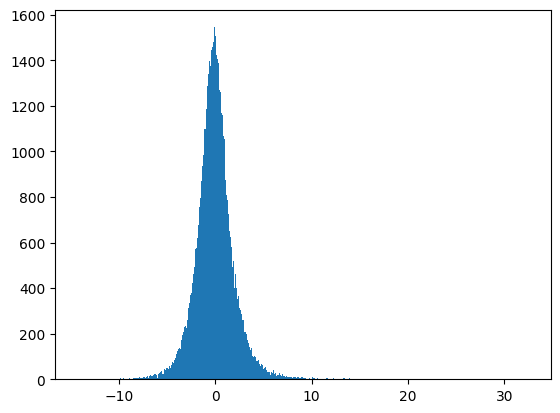

In [17]:
_ = plt.hist(y_diff,bins=1000)